In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import scipy.spatial as sp
import copy
import random
from time import time
from dolfinx import mesh

from Models import MyPoissonModel, VoronoiPoissonModel

[ 122.33274093 1134.4717205  2732.99118848 3253.61864167 2743.60362816
 1135.528871    131.84024074  116.22527906  917.01630833 2039.3600385
 2407.30909171 2067.47571379  909.37682625  112.44136421  105.47254322
  311.29051503  565.96085745  625.11200586  565.27831513  317.74682166
  103.55614992   97.06470891  112.45549455   96.70526552  106.9001078
  119.25186618   84.64333877  100.86641387   70.009659    269.08780666
  454.23858385  509.72063604  447.45277344  266.21540874   74.03706799
   46.44952662  629.68594896 1402.49773422 1573.29547081 1399.00659201
  653.50423667   64.10862628   24.74224732  583.65024162 1264.73648148
 1442.81944199 1270.18012894  579.07451086   32.62179985]


/opt/homebrew/Caskroom/miniconda/base/envs/pymc_no_fe_env/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


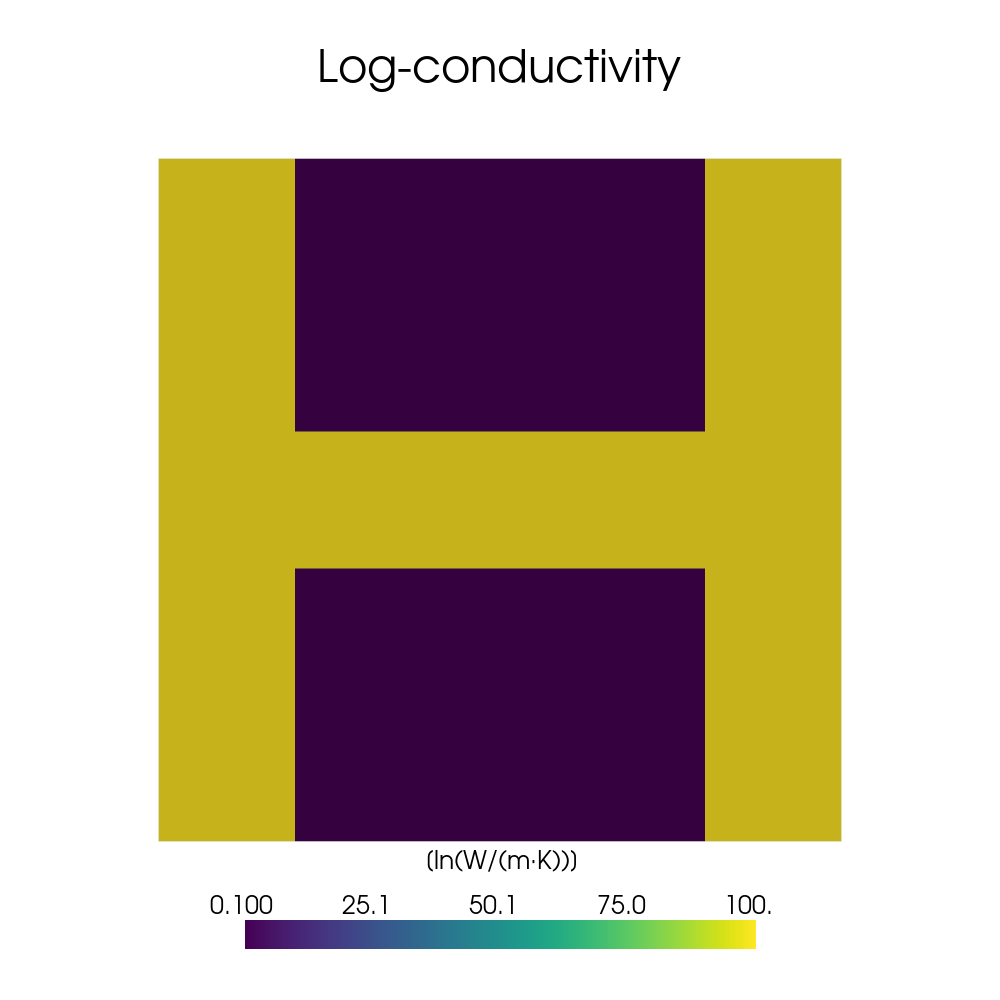

/opt/homebrew/Caskroom/miniconda/base/envs/pymc_no_fe_env/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


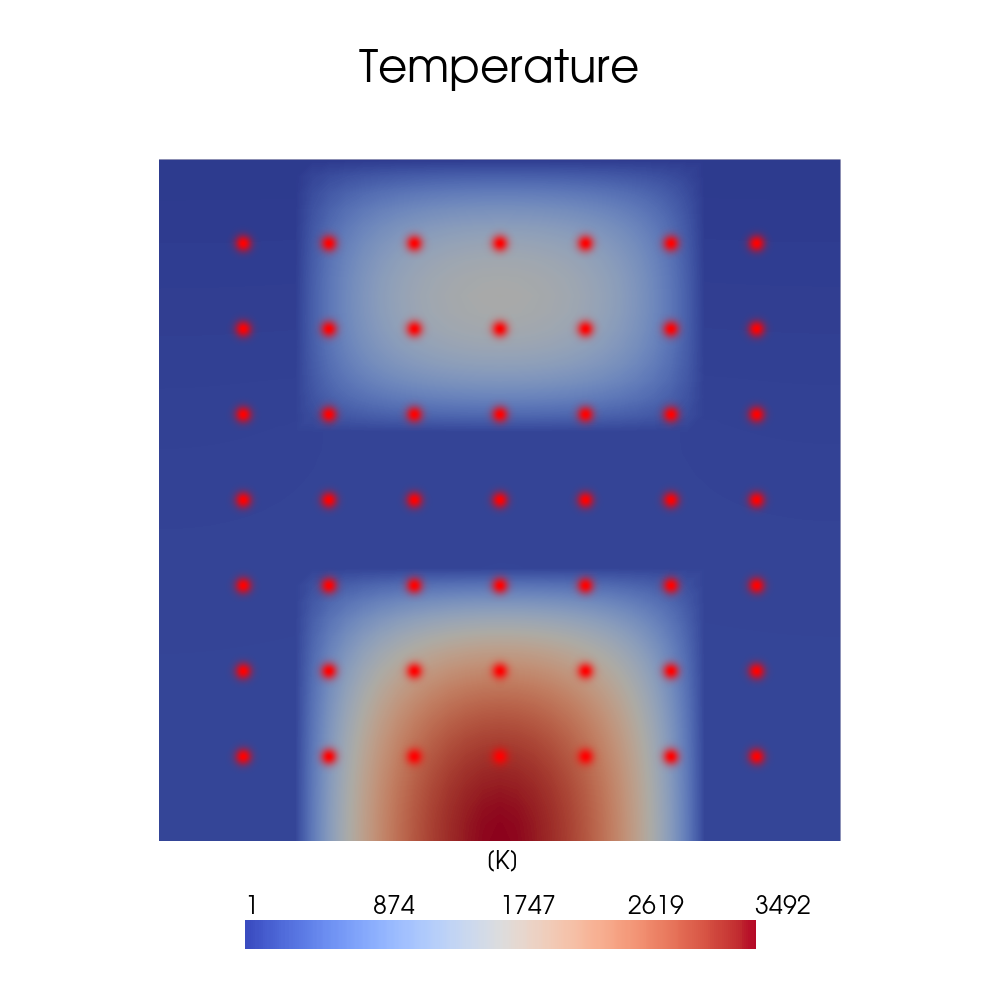

-23.56002593890986 3.729863850728534


In [3]:
lksigma = 9
X = np.linspace(0,1,9)[1:-1]
Y = np.linspace(0,1,9)[1:-1]
X, Y = np.meshgrid(X,Y)
points = np.hstack([X.reshape(-1,1),Y.reshape(-1,1)])
TrueModel = MyPoissonModel(f_val = 1e4, n_squares=40)
TrueModel.k.interpolate(lambda x : 1e-1*((x[0]<0.8)*(x[0]>0.2)*(x[1]<0.4) + (x[0]<0.8)*(x[0]>0.2)*(x[1]>0.6)) + 1e2*(1-((x[0]<0.8)*(x[0]>0.2)*(x[1]<0.4) + (x[0]<0.8)*(x[0]>0.2)*(x[1]>0.6))))
TrueModel.solve()
values = TrueModel.eval(points,"temperature")+st.norm(scale=lksigma).rvs(points.shape[0])
print(values)
measurements = np.hstack([points,values.reshape(-1,1)])
TrueModel.measurements = measurements
TrueModel.lksigma = lksigma
TrueModel.invcov = np.linalg.inv(lksigma**2*np.identity(TrueModel.measurements.shape[0]))
TrueModel.visualize("log-conductivity", measurements = TrueModel.measurements)
TrueModel.visualize("temperature", measurements = TrueModel.measurements)

diff = TrueModel.measurements[:,-1]-TrueModel.eval(measurements[:,:-1],"temperature")
ull = -0.5*np.linalg.matmul(np.linalg.matmul(diff, TrueModel.invcov), diff)
print(ull, np.mean(np.abs(diff)/TrueModel.eval(measurements[:,:-1],"temperature"))*100)

In [24]:
class VoronoiPoissonModel(MyPoissonModel):

    def __init__(self, true_params, measurements, n_squares=20, f_val=1000000, lksigma=1, orientation = 'v', k_space=("DG", 0), u_space=("Lagrange", 1), dirichlet_boundary_function=lambda x: np.isclose(x[1], 1), dirichlet_function=lambda x: x[1], neumann_boundary_function=lambda x: np.isclose(x[1], 0), neumann_function=lambda x: x[0]):
        super().__init__(n_squares, f_val, lksigma, k_space, u_space, dirichlet_boundary_function, dirichlet_function, neumann_boundary_function, neumann_function)
        self.midpoints = mesh.compute_midpoints(self.domain,self.tdim,np.array(range(self.n_squares**2)))[:,0:2]
        self.true_params = true_params 
        self.set_params(true_params)
        self.measurements = measurements
        self.invcov = np.linalg.inv(self.lksigma**2*np.identity(self.measurements.shape[0]))
        

    def set_params(self, params):
        """self.params = params
        midpoints = mesh.compute_midpoints(self.domain,self.tdim,np.array(range(self.n_squares**2)))[:,0:2]
        self.centers = self.params[2]
        self.k_regions = self.params[1]
        self.dim = self.params[0]
        for i in range(self.dim):
            if np.any(np.isclose(self.centers[i],midpoints)):
                self.centers[i] = [self.centers[i][0] + st.norm(scale=1/10/self.n_squares).rvs(), self.centers[i][1] + st.norm(scale=1/10/self.n_squares).rvs()]
        self.voronoi = sp.cKDTree(self.centers)
        self.k.x.array[0:] = np.exp(np.array(self.k_regions)[self.voronoi.query(mesh.compute_midpoints(self.domain,self.tdim,np.array(range(self.n_squares**2)))[:,0:2])[1]])
        self.params = [len(self.centers)]+[self.k_regions]+[self.centers]"""
        self.params = params
        self.centers = self.midpoints[self.params[2]]
        self.k_regions = self.params[1]
        self.dim = self.params[0]
        self.voronoi = sp.cKDTree(self.centers)
        self.k.x.array[0:] = np.exp(np.array(self.k_regions)[self.voronoi.query(mesh.compute_midpoints(self.domain,self.tdim,np.array(range(self.n_squares**2)))[:,0:2])[1]])
        self.params = [len(self.centers)]+[self.k_regions]+[self.centers]
        
    def visualize(self, magnitude, title=None):
        return super().visualize(magnitude, self.measurements, title)

In [25]:
Model = VoronoiPoissonModel(f_val = 1e4, n_squares = 40, true_params = [2, [np.log(1e2), np.log(1e-1), np.log(10)], [1,365,1000]], measurements = measurements, lksigma = lksigma)

/opt/homebrew/Caskroom/miniconda/base/envs/pymc_no_fe_env/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


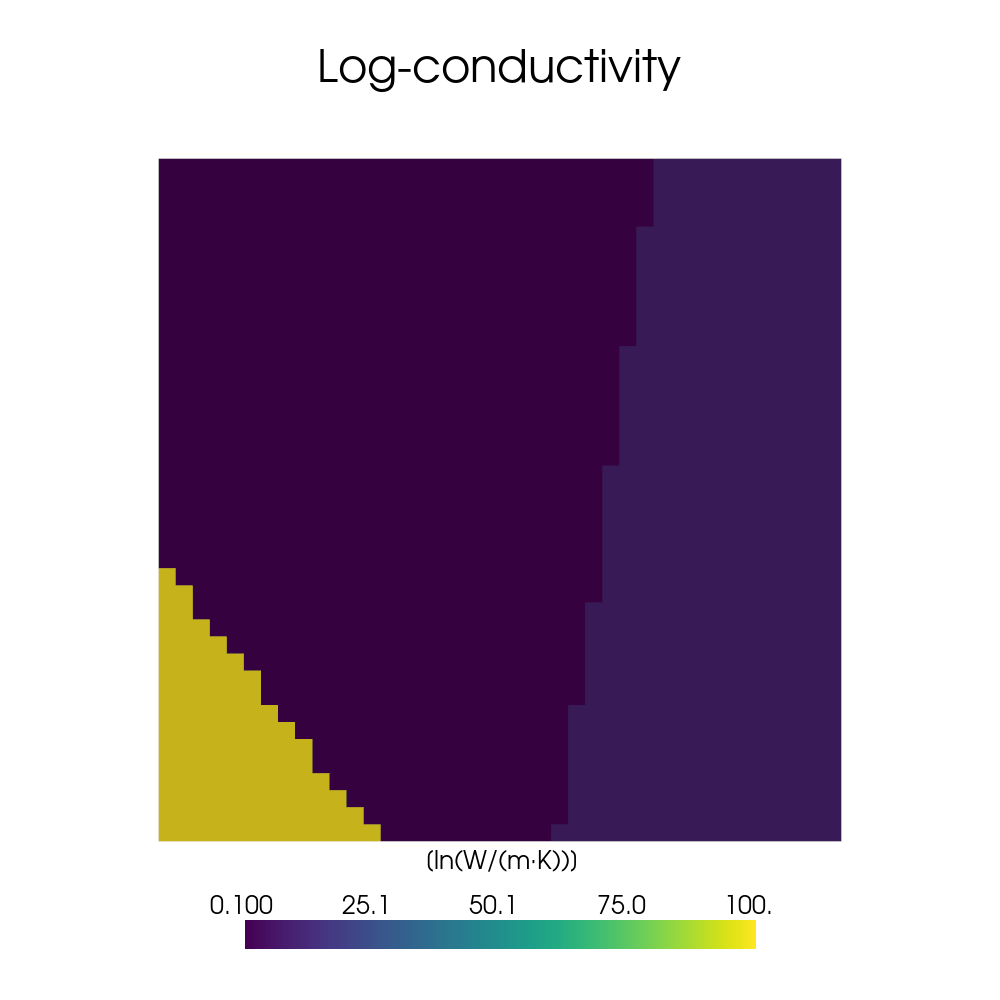

/opt/homebrew/Caskroom/miniconda/base/envs/pymc_no_fe_env/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


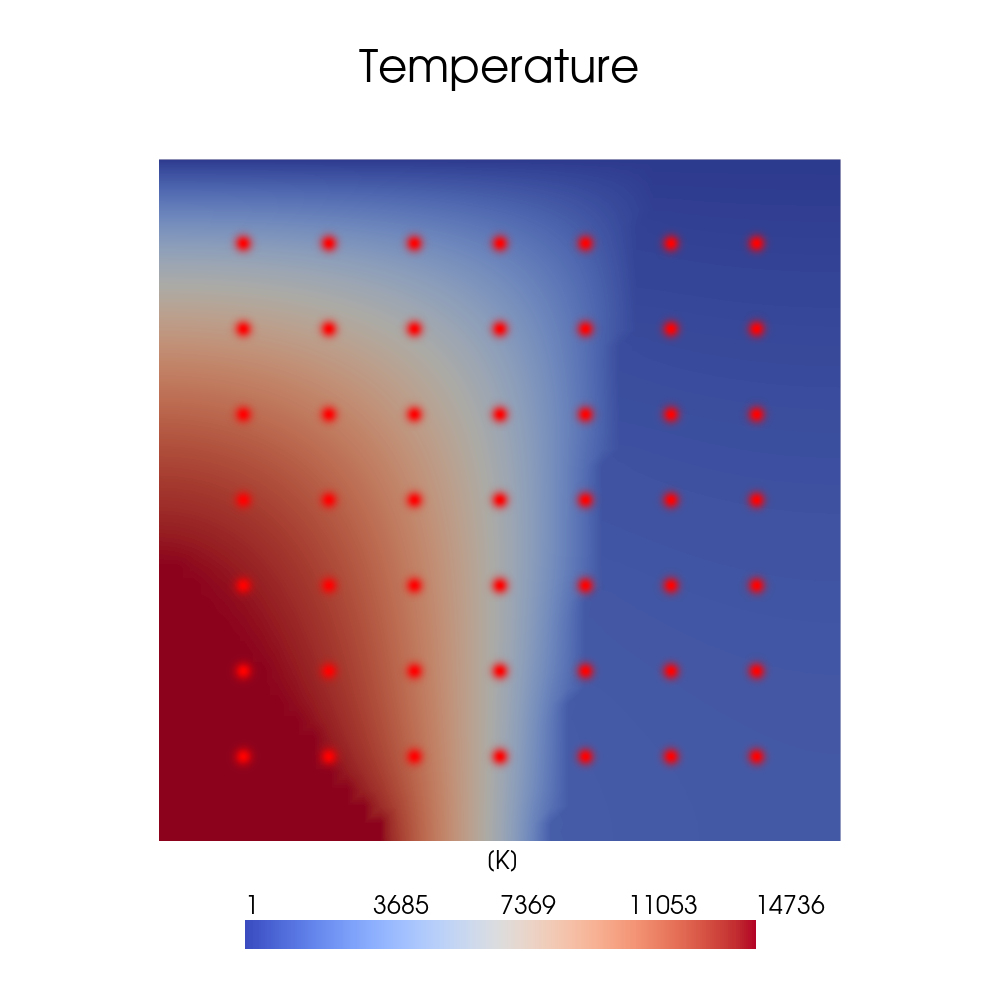

In [26]:
Model.visualize("log-conductivity")
Model.solve()
Model.visualize("temperature")

In [27]:
random.sample(range(40),3)


[33, 28, 4]

# Quadtrees

In [263]:
class Quadtree():
    def __init__(self, x0, y0, w, h, value):
        self.x0 = x0
        self.y0 = y0
        self.w = w
        self.h = h
        self.children = []
        self.value = value

    def compute_dimension(self):
        if len(self.children)>0:
            return sum([child.compute_dimension() for child in self.children])
        else:
            return 1
        
    def perturbe(self, std):
        if len(self.children)>0:
            quadtree = self.children[random.sample(range(4),1)[0]]
            quadtree.perturbe(std)
        else:
            self.value+st.norm(scale=std).rvs()


    def split(self, split_std):
        if len(self.children)>0:
            quadtree = self.children[random.sample(range(4),1)[0]]
            quadtree.split(split_std)
        else:
            self.children.append(Quadtree(self.x0-self.w/4, self.y0-self.h/4, self.w/2, self.h/2, self.value+st.norm(scale=split_std).rvs()))
            self.children.append(Quadtree(self.x0-self.w/4, self.y0+self.h/4, self.w/2, self.h/2, self.value+st.norm(scale=split_std).rvs()))
            self.children.append(Quadtree(self.x0+self.w/4, self.y0-self.h/4, self.w/2, self.h/2, self.value+st.norm(scale=split_std).rvs()))
            self.children.append(Quadtree(self.x0+self.w/4, self.y0+self.h/4, self.w/2, self.h/2, self.value+st.norm(scale=split_std).rvs()))

    def merge(self):
        candidates = [child for child in self.children if len(child.children)!=0]
        if len(candidates)!=0:
            child = random.sample(candidates, 1)[0]
            child.merge()
        else:
            self.value = np.mean(np.array([child.value for child in self.children]))
            self.children = []

    def eval(self, point):
        if len(self.children)>0:
            i = 1*(point[0]<self.x0)*(point[1]>self.y0) + 2*(point[0]>self.x0)*(point[1]<self.y0) + 3*(point[0]>self.x0)*(point[1]>self.y0)
            return self.children[i].eval(point)
        else:

            return self.value

In [264]:
q = Quadtree(0.5,0.5,1,1,10)

In [277]:
q.split(split_std=10)

In [280]:
q.compute_dimension()

322

In [279]:
for _ in range(100):
    q.split(split_std=10)

In [281]:
X = np.linspace(0,1,100)
Y = np.linspace(0,1,100)
X, Y = np.meshgrid(X,Y)
points = np.hstack([X.reshape(-1,1), Y.reshape(-1,1)])
values = np.array([q.eval(point) for point in points])

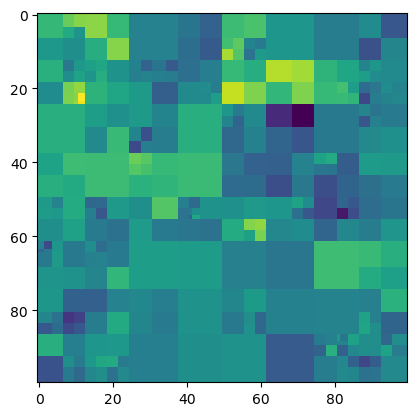

In [282]:
plt.imshow(values.reshape((100,100)))

In [239]:
q.children[3].children[3].x0

0.875

# Old

In [118]:
class VoronoiPrior:

    def __init__(self, dim_min, dim_max, k_min, k_max):
        self.dimprior = st.randint(low=dim_min, high=dim_max+1)
        self.lnkrvs = st.uniform(np.log(k_min), np.log(k_max)-np.log(k_min))

    def draw(self, dim=None):
        if dim==None:
            dim = int(self.dimprior.rvs(1))
        centers = [center for center in np.random.uniform(0,1,(dim,2))]
        return [dim, list(self.lnkrvs.rvs(size=dim)), centers]
    
    def logeval_transform(self, params):
        return np.log(self.dimprior.pmf(params[0]))+np.sum([np.log(self.lnkrvs.pdf(lnk)) for lnk in params[1]])

class VoronoiProposer:

    def __init__(self, params=[1,[0],[[0.5,0.5]]], lnk_var=1, center_var=1, dim_min=1, dim_max=np.inf, std=1, pbirth=0, pdeath=0):
        self.params = params
        self.dim_min = dim_min
        self.dim_max = dim_max
        self.lnk_stds = list(np.sqrt(lnk_var)*np.ones(self.params[0]))
        self.center_stds = list(np.sqrt(center_var)*np.ones(self.params[0]))
        self.birth_rvs = st.norm(loc=0, scale=std)
        self.pbirth = pbirth
        self.pdeath = pdeath
        self.p = 1
        self.detjacobian = 1 #Jacobian of the birth-death transformation

    def compute_detjacobian(self):
        self.detjacobian = 1
    
    def move(self, new_params):
        self.params = copy.deepcopy(new_params)
        if self.params[0]!=len(self.lnk_stds):
            self.lnk_stds = [self.lnk_stds[0] for _ in range(self.params[0])]
            self.center_stds = [self.center_stds[0] for _ in range(self.params[0])]

    def perturbate(self):
        index = random.randint(0,self.params[0]-1)
        dim, lnks, centers = self.params[0], copy.deepcopy(self.params[1]), copy.deepcopy(self.params[2])
        lnks[index] += st.norm(loc=0, scale=self.lnk_stds[index]).rvs()
        centers[index][0] += st.norm(loc=0, scale=self.center_stds[index]).rvs()
        centers[index][1] += st.norm(loc=0, scale=self.center_stds[index]).rvs()
        proposal = [dim, lnks, centers]
        return proposal, index
    
    def birth(self):
        padding_params = self.birth_rvs.rvs()
        proposal = copy.deepcopy(self.params)
        self.compute_detjacobian()
        center = list(np.random.uniform(0,1,2))
        index = sp.cKDTree(self.params[2]).query(center)[1]
        proposal[2].append(center)
        proposal[1].append(proposal[1][index] + padding_params)
        proposal[0] += 1
        return proposal, padding_params, index

    def death(self):
        proposal = copy.deepcopy(self.params)
        index = random.randint(0,proposal[0]-1)
        center = proposal[2][index]
        proposal[2].pop(index)
        proposal[1].pop(index)
        tree_index = sp.cKDTree(proposal[2]).query(center)[1]
        padding_params = self.params[1][index]-proposal[1][tree_index]
        self.compute_detjacobian()
        proposal[0] -= 1
        
        return proposal, padding_params, index
    
    def propose_process(self):
        #0 split, 1 merge, 2 move
        if self.params[0]<self.dim_max and self.params[0]>self.dim_min:
            u = random.uniform(0,1)
            if u<self.pbirth:
                return 0
            elif u<self.pbirth+self.pdeath:
                return 1
            else:
                return 2
        elif self.params[0]>=self.dim_max and self.params[0]>self.dim_min: #Cannot split
            u = random.uniform(0,1-self.pbirth)
            if u<self.pdeath:
                return 1
            else:
                return 2
        elif self.params[0]<self.dim_max and self.params[0]>=self.dim_min: #Cannot merge
            u = random.uniform(0,1-self.pbirth)
            if u<self.pdeath:
                return 0
            else:
                return 2
        else: #Cannot split nor merge
            return 2
    
    def propose(self):
        choice = self.propose_process()
        if choice==0:
                proposal, padding_params, index = self.birth()    
                self.p = self.pdeath/self.pbirth/self.birth_rvs.pdf(padding_params)*self.detjacobian
        elif choice==1:
                proposal, padding_params, index = self.death()
                self.p = self.pbirth*self.birth_rvs.pdf(padding_params)/self.pdeath/self.detjacobian
        else:
            proposal, index = self.perturbate()
            self.p = 1 #If no split or merge, it is a symmetrical rwmh
        return proposal, index

class VoronoiPoissonSampler:

    def __init__(self, Model, Prior, Proposer, init_params):

        self.model = Model
        self.prior = Prior
        self.proposer = Proposer
        self.init_params = copy.deepcopy(init_params)
        self.params_chains = []
        self.proposal_chains = []
        self.acceptance_chains = []
        self.u_chains = []
        self.lnk_sigma_chains = []
        self.center_sigma_chains = []
        self.ull_chains = []
        self.proposals = []
        self.times = []

        self.reset(self.init_params)

    def reset(self, init_params):
            if init_params[0]!=None: #If dimension is predetermined, we must check if anything else is
                self.params0 = self.prior.draw(dim=init_params[0])
                for i in range(1,len(init_params)):
                    if init_params[i] is not None:
                        self.params0[i] = copy.deepcopy(init_params[i]) #We asume all non-dimension parameters are iterable
            else: #If dimension is not predetermined, draw all parameters randomly
                self.params0 = self.prior.draw()
            """i = 0
            while self.prior.logeval_transform(self.params0)<=-np.inf and i<=100:
                i += 1
                if init_params[0]!=None: #If dimension is predetermined, we must check if anything else is
                    self.params0 = self.prior.draw(dim=init_params[0])
                    for i in range(1,len(init_params)):
                        if init_params[i] is not None:
                            self.params0[i] = copy.deepcopy(init_params[i]) #We asume all non-dimension parameters are iterable
                else: #If dimension is not predetermined, draw all parameters randomly
                    self.params0 = self.prior.draw()
            if i>100:
                print("Noup :(")"""

            self.proposer.move(self.params0)
            self.model.set_params(self.params0)
            self.lnprior0 = self.prior.logeval_transform(self.params0) #Evaluate probability
            self.model.solve()
            self.u0 = self.model.eval(self.model.measurements[:,:-1],"temperature")
            self.ull0= self.compute_unnormalized_loglikelihood()
            self.paramsf = copy.deepcopy(self.params0)
            self.lnpriorf = self.lnprior0
            self.uf = copy.deepcopy(self.u0)
            self.ullf = self.compute_unnormalized_loglikelihood()
        
    def compute_unnormalized_loglikelihood(self):
        dif = self.model.measurements[:,-1]-self.model.eval(points=self.model.measurements[:,:-1], magnitude='temperature')
        ull = -0.5*np.matmul(np.matmul(dif,self.model.invcov),dif.T)
        return ull

    def accept_reject(self):
        if self.lnprior0 == -np.inf and self.lnpriorf != -np.inf:
            return True
        elif self.lnpriorf == -np.inf and self.lnprior0 != -np.inf:
            return False
        else:
            alpha = min(0, self.ullf-self.ull0+self.lnpriorf-self.lnprior0+np.log(self.proposer.p))
            u = np.random.uniform()
            accept = (alpha>np.log(u))
            return accept
    
    def propose(self):
        start = time()
        self.paramsf, _ = self.proposer.propose()
        propose_time = time()-start

        start = time()
        self.model.set_params(self.paramsf)
        conductivity_time = time()-start

        start = time()
        self.lnpriorf = self.prior.logeval_transform(self.paramsf) #Evaluate probability
        prior_time = time()-start

        start = time()
        self.model.solve() #Find new temperature
        solve_time = time()-start

        self.uf = self.model.eval(self.model.measurements[:,:-1],"temperature")

        start = time()
        self.ullf = self.compute_unnormalized_loglikelihood()
        ull_time =  time()-start
        return [propose_time, conductivity_time, prior_time, solve_time, ull_time]

    def adapt_proposer(self, t, n_iter, acceptance_rate):
        if self.proposer.pbirth*self.proposer.pdeath==0:
            delta = 0.01
            if t%50==0 and t<n_iter//2:
                lnk_sigma = np.exp(np.log(self.proposer.lnk_rvs.std())+(-int(acceptance_rate<=0.234)+int(acceptance_rate>=0.3))*delta)
                self.proposer.lnk_rvs = st.norm(scale=lnk_sigma)

    def perform_step(self, acceptance):
        times = self.propose()
        self.proposals[-1].append(copy.deepcopy(self.paramsf))
        start = time()
        if self.accept_reject():
            self.params0, self.lnprior0, self.u0, self.ull0  = copy.deepcopy(self.paramsf), self.lnpriorf, copy.deepcopy(self.uf), self.ullf
            self.proposer.move(self.params0)
            acceptance += 1
        times.append(time()-start)
        self.params_chains[-1].append(self.params0)
        self.proposal_chains[-1].append(self.paramsf)
        self.acceptance_chains[-1].append(acceptance/len(self.params_chains[-1]))
        self.u_chains[-1].append(copy.deepcopy(self.u0))
        self.lnk_sigma_chains[-1].append(self.proposer.lnk_stds[0]) #To be fixed
        self.center_sigma_chains[-1].append(self.proposer.center_stds[0]) #To be fixed
        self.ull_chains[-1].append(self.ull0)
        self.times[-1].append(times)
        return acceptance

    def draw_chain(self, n_iter):
        self.reset(self.init_params)
        self.params_chains.append([self.params0])
        self.proposal_chains.append([self.paramsf])
        self.acceptance_chains.append([0])
        self.u_chains.append([self.model.eval(self.model.measurements[:,:-1],"temperature")])
        self.lnk_sigma_chains.append([self.proposer.lnk_stds[0]]) #To be fixed
        self.center_sigma_chains.append([self.proposer.center_stds[0]]) #To be fixed
        self.ull_chains.append([self.ull0])
        self.proposals.append([copy.deepcopy(self.paramsf)])
        self.times.append([[0,0,0,0,0,0]])
        acceptance = 0
        print("Start successfull!")
        for t in range(n_iter):
            acceptance = self.perform_step(acceptance)
            acceptance_rate = acceptance/(t+1)
            self.adapt_proposer(t, n_iter, acceptance_rate)
    
    def draw_chains(self, n_iter, n_chains=1):
        for _ in range(n_chains):
            self.draw_chain(n_iter)

In [119]:
Prior = VoronoiPrior(dim_min=1, dim_max=100, k_min=1e-2, k_max=1e3)
Proposer = VoronoiProposer(params=[1,[0],[[0.5,0.5]]], lnk_var=1e-1, center_var=0, dim_min=1, dim_max=100, std=1, pbirth=1/3, pdeath=1/3)
Sampler = VoronoiPoissonSampler(Model, Prior, Proposer, init_params=Prior.draw())

In [120]:
n_iter = 100000
Sampler.draw_chain(n_iter=n_iter)

Start successfull!


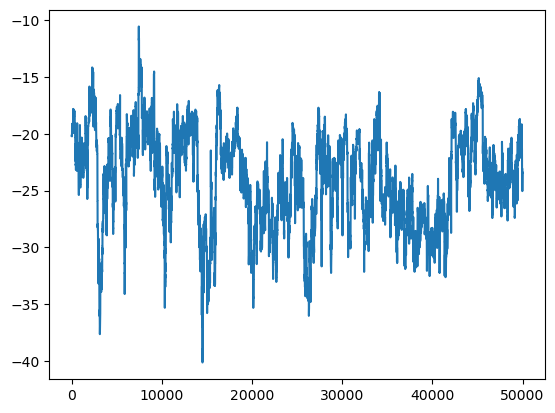

In [121]:
plt.plot(range(n_iter//2+1), Sampler.ull_chains[-1][n_iter//2:])

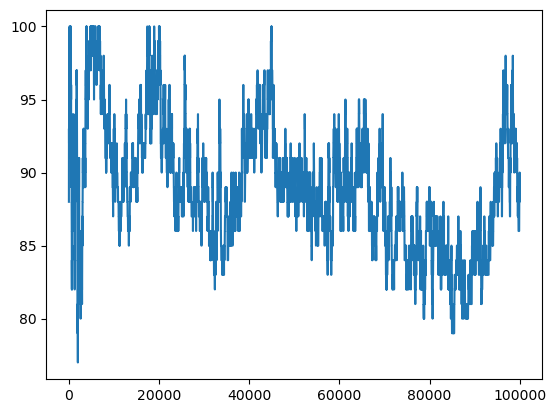

In [122]:
plt.plot(range(n_iter+1), [param[0] for param in Sampler.params_chains[-1]])

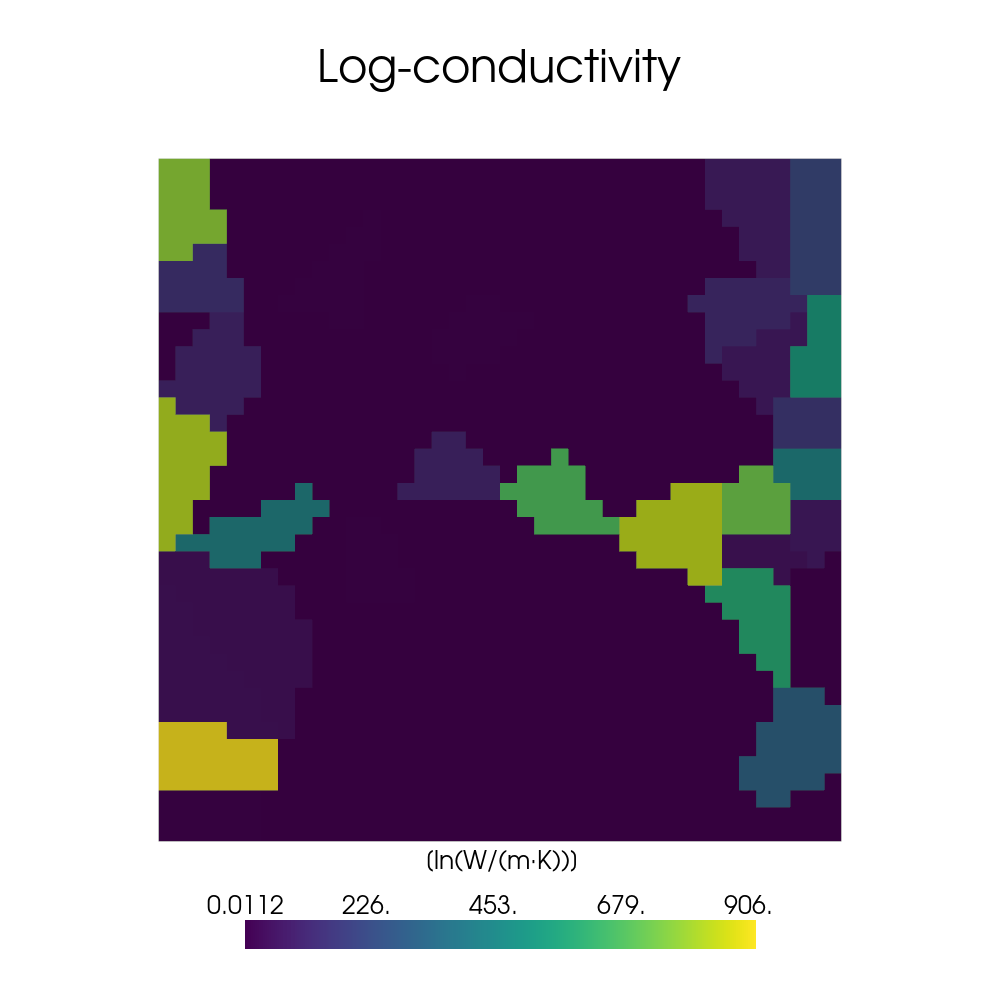

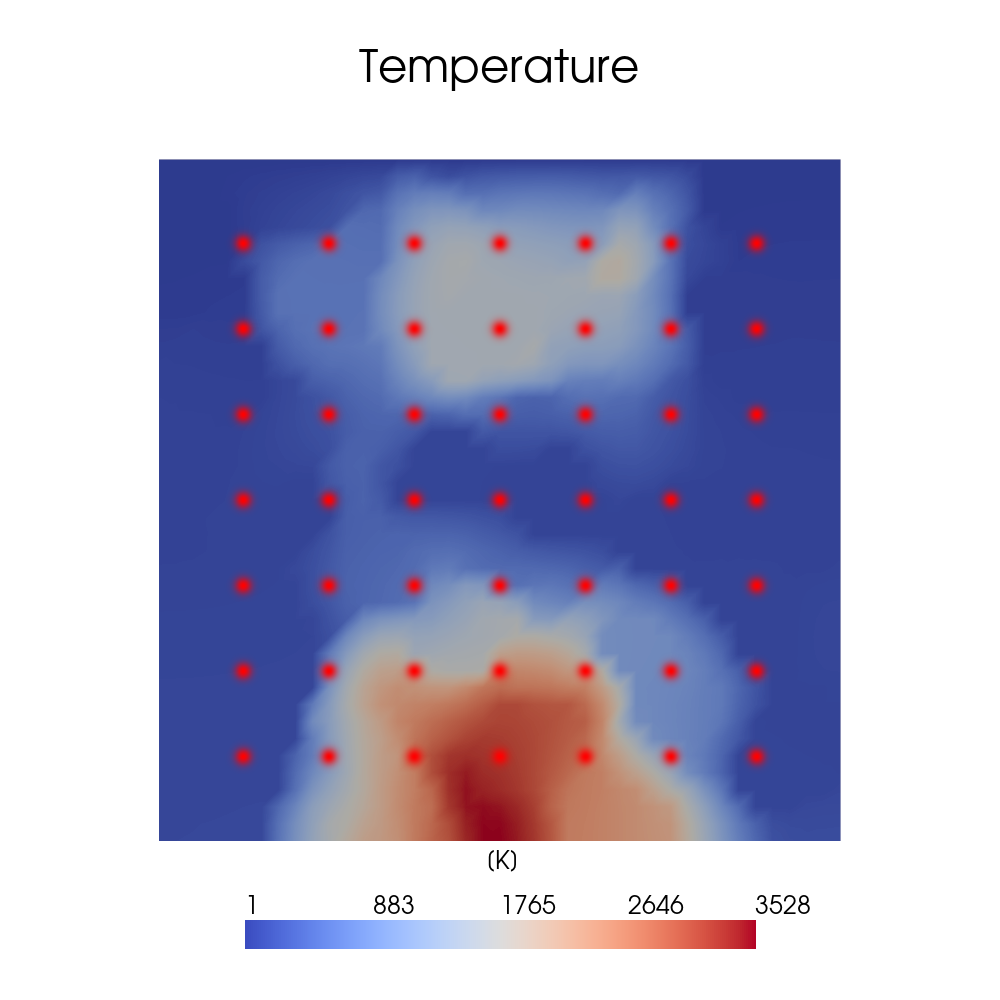

In [123]:
Model.set_params(Sampler.params_chains[-1][-1])
Model.solve()
Model.visualize("log-conductivity")
Model.visualize("temperature")

In [126]:
start = time()
Model.set_params(Sampler.params_chains[-1][-20])
print((time()-start)*n_iter/60)

17.61317253112793


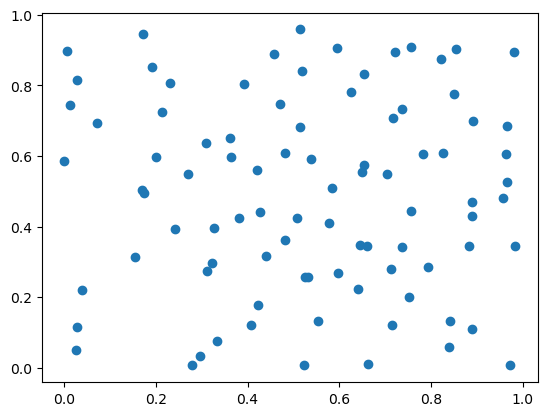

In [124]:
plt.scatter(np.array(Sampler.params_chains[-1][-1][2])[:,0], np.array(Sampler.params_chains[-1][-1][2])[:,1])

In [125]:
Sampler.params_chains[-1][-1][0]

89

In [100]:
Model.n_squares

20